In [1]:
import os

# Automatically find the uploaded garbage_classification folder
DATASET_PATH = None

for root, dirs, files in os.walk("/kaggle/input"):
    if os.path.basename(root) == "garbage_classification":
        DATASET_PATH = root
        break

print("Dataset path:")
print(DATASET_PATH)

# Verify classes
classes = ["hazardous", "organic", "recyclable"]

print("\nClass counts:")

total = 0

for class_name in classes:
    class_path = os.path.join(DATASET_PATH, class_name)

    files = [
        f for f in os.listdir(class_path)
        if os.path.isfile(os.path.join(class_path, f))
    ]

    count = len(files)
    total += count

    print(f"{class_name:12}: {count}")

print("-" * 30)
print(f"{'TOTAL':12}: {total}")

Dataset path:
/kaggle/input/datasets/teja67/garbage-classification/garbage_classification

Class counts:
hazardous   : 2720
organic     : 2289
recyclable  : 14115
------------------------------
TOTAL       : 19124


In [2]:
# ==========================================
# CREATE BALANCED DATASET
# 2289 IMAGES PER CLASS
# ==========================================

import os
import shutil
import random

random.seed(42)

BALANCED_DIR = "/kaggle/working/balanced_dataset"

# Remove old balanced dataset if it exists
if os.path.exists(BALANCED_DIR):
    shutil.rmtree(BALANCED_DIR)

# Create class folders
for class_name in ["hazardous", "organic", "recyclable"]:
    os.makedirs(
        os.path.join(BALANCED_DIR, class_name),
        exist_ok=True
    )

TARGET_COUNT = 2289

print("Creating balanced dataset...\n")

for class_name in ["hazardous", "organic", "recyclable"]:

    source_dir = os.path.join(DATASET_PATH, class_name)
    destination_dir = os.path.join(BALANCED_DIR, class_name)

    files = [
        f for f in os.listdir(source_dir)
        if os.path.isfile(os.path.join(source_dir, f))
    ]

    # Randomly select exactly 2289 images
    selected_files = random.sample(files, TARGET_COUNT)

    # Copy selected images
    for filename in selected_files:
        shutil.copy2(
            os.path.join(source_dir, filename),
            os.path.join(destination_dir, filename)
        )

    print(f"{class_name:12}: {len(selected_files)} images")

print("\nBalanced dataset created successfully.")
print("Location:", BALANCED_DIR)

Creating balanced dataset...

hazardous   : 2289 images
organic     : 2289 images
recyclable  : 2289 images

Balanced dataset created successfully.
Location: /kaggle/working/balanced_dataset


In [3]:
# ==========================================
# BALANCED DATASET SPLIT
# 70% TRAIN / 15% VALIDATION / 15% TEST
# ==========================================

import os
import shutil
import random

random.seed(42)

SPLIT_DIR = "/kaggle/working/balanced_split"

# Remove previous split if it exists
if os.path.exists(SPLIT_DIR):
    shutil.rmtree(SPLIT_DIR)

# Create folders
for split in ["train", "validation", "test"]:
    for class_name in ["hazardous", "organic", "recyclable"]:
        os.makedirs(
            os.path.join(SPLIT_DIR, split, class_name),
            exist_ok=True
        )

TRAIN_RATIO = 0.70
VAL_RATIO = 0.15

classes = ["hazardous", "organic", "recyclable"]

print("Creating balanced train/validation/test split...\n")

for class_name in classes:

    source_dir = os.path.join(BALANCED_DIR, class_name)

    files = [
        f for f in os.listdir(source_dir)
        if os.path.isfile(os.path.join(source_dir, f))
    ]

    random.shuffle(files)

    total = len(files)

    train_end = int(total * TRAIN_RATIO)
    val_end = train_end + int(total * VAL_RATIO)

    train_files = files[:train_end]
    val_files = files[train_end:val_end]
    test_files = files[val_end:]

    # Copy training files
    for filename in train_files:
        shutil.copy2(
            os.path.join(source_dir, filename),
            os.path.join(SPLIT_DIR, "train", class_name, filename)
        )

    # Copy validation files
    for filename in val_files:
        shutil.copy2(
            os.path.join(source_dir, filename),
            os.path.join(SPLIT_DIR, "validation", class_name, filename)
        )

    # Copy test files
    for filename in test_files:
        shutil.copy2(
            os.path.join(source_dir, filename),
            os.path.join(SPLIT_DIR, "test", class_name, filename)
        )

    print(
        f"{class_name:12} | "
        f"Train: {len(train_files)} | "
        f"Validation: {len(val_files)} | "
        f"Test: {len(test_files)}"
    )

print("\nSplit completed successfully.")
print("Location:", SPLIT_DIR)

Creating balanced train/validation/test split...

hazardous    | Train: 1602 | Validation: 343 | Test: 344
organic      | Train: 1602 | Validation: 343 | Test: 344
recyclable   | Train: 1602 | Validation: 343 | Test: 344

Split completed successfully.
Location: /kaggle/working/balanced_split


In [4]:
import tensorflow as tf

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    "/kaggle/working/balanced_split/train",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=42
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    "/kaggle/working/balanced_split/validation",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    "/kaggle/working/balanced_split/test",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("\nClasses:", train_ds.class_names)

print("\nDataset sizes:")
print("Train:", tf.data.experimental.cardinality(train_ds).numpy(), "batches")
print("Validation:", tf.data.experimental.cardinality(val_ds).numpy(), "batches")
print("Test:", tf.data.experimental.cardinality(test_ds).numpy(), "batches")

Found 4788 files belonging to 3 classes.


I0000 00:00:1789970384.320404      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1789970384.323292      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 1026 files belonging to 3 classes.
Found 1031 files belonging to 3 classes.

Classes: ['hazardous', 'organic', 'recyclable']

Dataset sizes:
Train: 150 batches
Validation: 33 batches
Test: 33 batches


In [5]:
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Input(shape=(224, 224, 3)),

    # Normalize pixel values
    layers.Rescaling(1./255),

    # Data augmentation
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),

    # CNN feature extraction
    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(256, (3, 3), activation="relu"),
    layers.MaxPooling2D(),

    # Classification
    layers.GlobalAveragePooling2D(),

    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),

    layers.Dense(3, activation="softmax")
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip (RandomFlip)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 224, 224, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 421,699 (1.61 MB)

 Trainable params: 421,699 (1.61 MB)

 Non-trainable params: 0 (0.00 B)

In [6]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=6,
        restore_best_weights=True,
        verbose=1
    ),

    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-7,
        verbose=1
    ),

    ModelCheckpoint(
        "/kaggle/working/balanced_waste_cnn_best.keras",
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    )
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=callbacks
)

Epoch 1/30
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.4222 - loss: 1.0625
Epoch 1: val_loss improved from None to 0.93450, saving model to /kaggle/working/balanced_waste_cnn_best.keras

Epoch 1: finished saving model to /kaggle/working/balanced_waste_cnn_best.keras
150/150 ━━━━━━━━━━━━━━━━━━━━ 21s 98ms/step - accuracy: 0.4733 - loss: 1.0169 - val_accuracy: 0.5224 - val_loss: 0.9345 - learning_rate: 1.0000e-04
Epoch 2/30
149/150 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - accuracy: 0.5442 - loss: 0.9396
Epoch 2: val_loss improved from 0.93450 to 0.87180, saving model to /kaggle/working/balanced_waste_cnn_best.keras

Epoch 2: finished saving model to /kaggle/working/balanced_waste_cnn_best.keras
150/150 ━━━━━━━━━━━━━━━━━━━━ 14s 91ms/step - accuracy: 0.5572 - loss: 0.9179 - val_accuracy: 0.6004 - val_loss: 0.8718 - learning_rate: 1.0000e-04
Epoch 3/30
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - accuracy: 0.5763 - loss: 0.9153
Epoch 3: val_loss improved from 0.87180 to 0.83743, saving

In [7]:
test_loss, test_accuracy = model.evaluate(test_ds, verbose=1)

print("\nTest Loss:", test_loss)
print("Test Accuracy:", test_accuracy)
print("Test Accuracy (%):", test_accuracy * 100)

33/33 ━━━━━━━━━━━━━━━━━━━━ 3s 85ms/step - accuracy: 0.7100 - loss: 0.7115

Test Loss: 0.7115296125411987
Test Accuracy: 0.7099903225898743
Test Accuracy (%): 70.99903225898743


In [8]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

# Get true labels
y_true = np.concatenate([y.numpy() for x, y in test_ds], axis=0)

# Get predictions
y_pred_probs = model.predict(test_ds)
y_pred = np.argmax(y_pred_probs, axis=1)

# Classification report
print("Classification Report:\n")
print(
    classification_report(
        y_true,
        y_pred,
        target_names=train_ds.class_names
    )
)

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

print("\nConfusion Matrix:")
print(cm)

33/33 ━━━━━━━━━━━━━━━━━━━━ 3s 73ms/step
Classification Report:

              precision    recall  f1-score   support

   hazardous       0.69      0.77      0.73       343
     organic       0.71      0.81      0.76       344
  recyclable       0.74      0.55      0.63       344

    accuracy                           0.71      1031
   macro avg       0.71      0.71      0.71      1031
weighted avg       0.71      0.71      0.71      1031


Confusion Matrix:
[[265  44  34]
 [ 32 278  34]
 [ 87  68 189]]


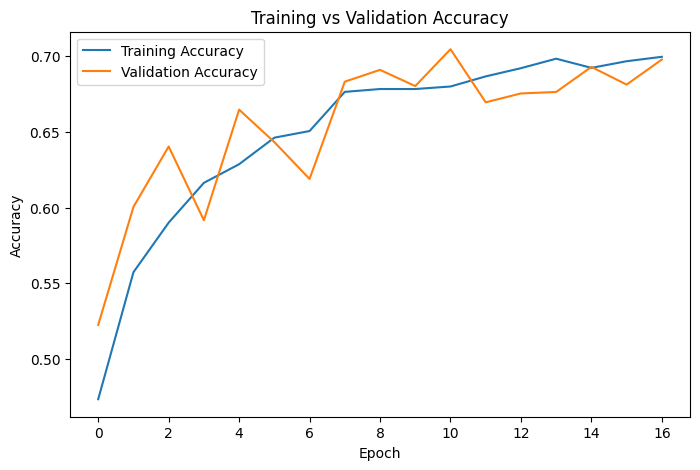

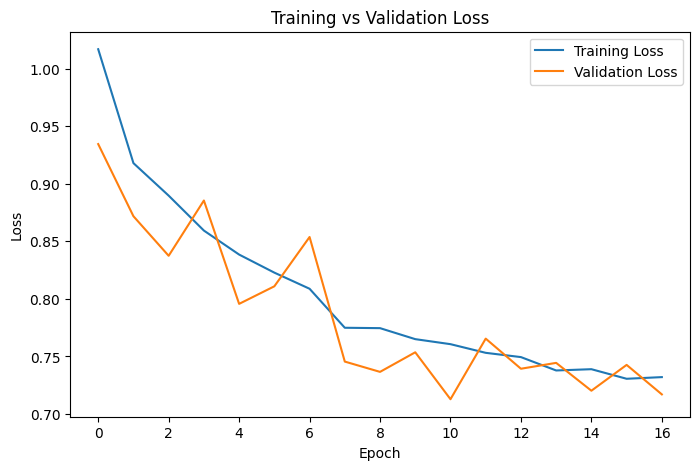

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

In [10]:
import os

original_path = "/kaggle/input/datasets/teja67/garbage-classification/garbage_classification"

for folder in sorted(os.listdir(original_path)):
    path = os.path.join(original_path, folder)

    if os.path.isdir(path):
        print(f"\n{folder}: {len(os.listdir(path))} images")


hazardous: 2720 images

organic: 2289 images

recyclable: 14115 images


In [11]:
import io
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import ipywidgets as widgets
from IPython.display import display, clear_output

class_names = ['hazardous', 'organic', 'recyclable']

# Upload widget
upload = widgets.FileUpload(
    accept='image/*',
    multiple=False,
    description='Choose Image'
)

# Predict button
predict_button = widgets.Button(
    description='Predict',
    button_style='success'
)

output = widgets.Output()

display(upload)
display(predict_button)
display(output)


def predict_image(button):
    with output:
        clear_output()

        if not upload.value:
            print("Please choose an image first.")
            return

        # Handle different ipywidgets versions
        if isinstance(upload.value, dict):
            file_info = list(upload.value.values())[0]
        else:
            file_info = upload.value[0]

        image_data = file_info['content']

        # Open image
        image = Image.open(io.BytesIO(image_data)).convert('RGB')

        # Display original image
        plt.figure(figsize=(5, 5))
        plt.imshow(image)
        plt.axis("off")
        plt.show()

        # Resize for CNN
        img = image.resize((224, 224))

        # Convert to numpy
        img_array = np.array(img, dtype=np.float32)

        # Add batch dimension
        img_array = np.expand_dims(img_array, axis=0)

        # Prediction
        predictions = model.predict(img_array, verbose=0)[0]

        predicted_index = np.argmax(predictions)
        predicted_class = class_names[predicted_index]
        confidence = predictions[predicted_index] * 100

        print("=" * 40)
        print("PREDICTION")
        print("=" * 40)
        print(f"Class      : {predicted_class.upper()}")
        print(f"Confidence : {confidence:.2f}%")

        print("\nClass Probabilities:")
        for name, probability in zip(class_names, predictions):
            print(f"{name:12}: {probability * 100:.2f}%")


predict_button.on_click(predict_image)

FileUpload(value=(), accept='image/*', description='Choose Image')

Button(button_style='success', description='Predict', style=ButtonStyle())

Output()